In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows',80)
pd.set_option('display.max_columns',80)

In [3]:
df=pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
print(df.info())
print(df)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
df['MSZoning']=df['MSZoning'].fillna('None')
df['MSZoning'].unique()
df['Alley']=df['Alley'].fillna('NotProv.')
df['Alley'].unique()
df['Utilities']=df['Utilities'].fillna('NotProv.')
df['Utilities'].unique()
df['SaleType']=df['SaleType'].fillna('NotProv.')
df['SaleType'].unique()
df['Fence']=df['Fence'].fillna('None.')
df['Fence'].unique()

array(['None.', 'MnPrv', 'GdWo', 'GdPrv', 'MnWw'], dtype=object)

<Axes: xlabel='SaleCondition', ylabel='count'>

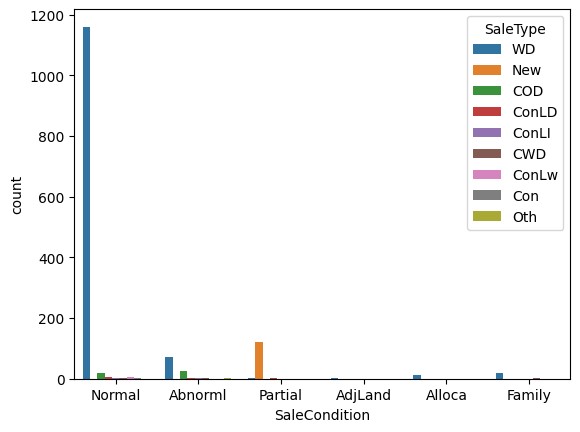

In [5]:
years=np.arange(2005,2011,1)
sns.countplot(x='SaleCondition', hue='SaleType', data=df )

<Axes: xlabel='YrSold', ylabel='SalePrice'>

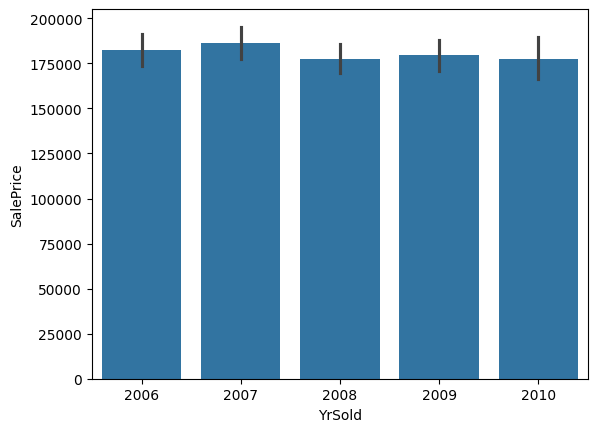

In [6]:
sns.barplot(x='YrSold', y='SalePrice', data=df)

In [7]:
df["SalePrice"]

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

<Axes: xlabel='SalePrice', ylabel='Count'>

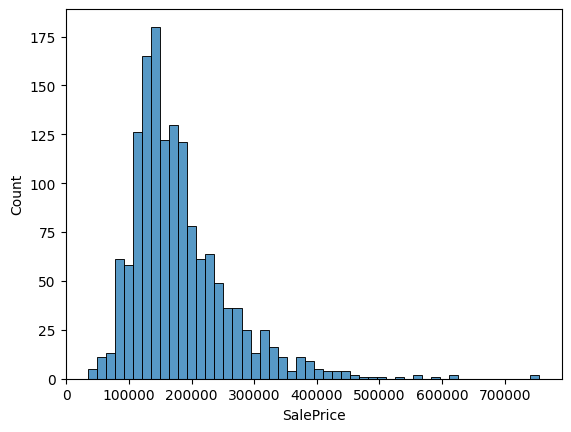

In [8]:
sns.histplot(df["SalePrice"], bins=50)


In [9]:
df['Date'] = pd.to_datetime(
    df['YrSold'].astype(str) + '-' + df['MoSold'].astype(str) + '-01'
)
df['Month']=df['Date'].dt.month_name()
df['Month']


0        February
1             May
2       September
3        February
4        December
          ...    
1455       August
1456     February
1457          May
1458        April
1459         June
Name: Month, Length: 1460, dtype: object

<Axes: >

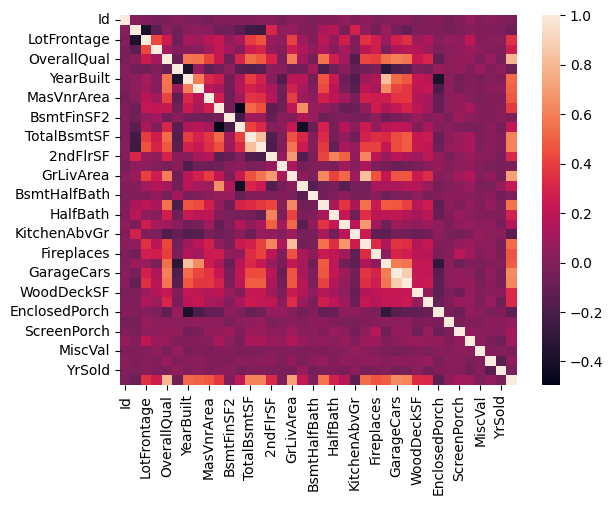

In [10]:
df_mat=df.corr(numeric_only=True)
df_mat["SalePrice"].sort_values(ascending=False).head(10)
sns.heatmap(df_mat)

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 40.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 39.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 40.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 39.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 18.9% of the points cannot be plac

<Axes: xlabel='YrSold', ylabel='SalePrice'>

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 45.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 44.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 44.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 22.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


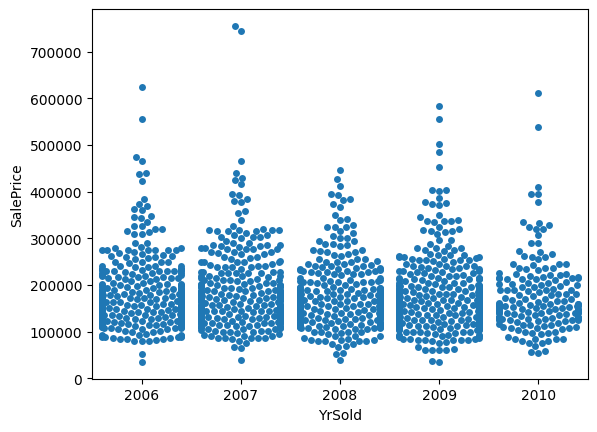

In [11]:
sns.swarmplot(x='YrSold', y='SalePrice', data=df)

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

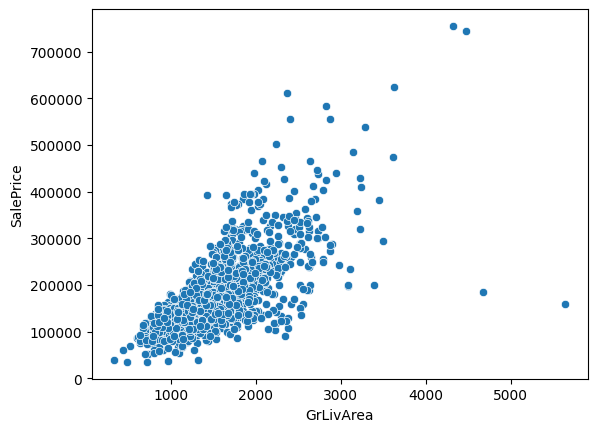

In [12]:
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df)

<Axes: xlabel='SaleCondition', ylabel='SalePrice'>

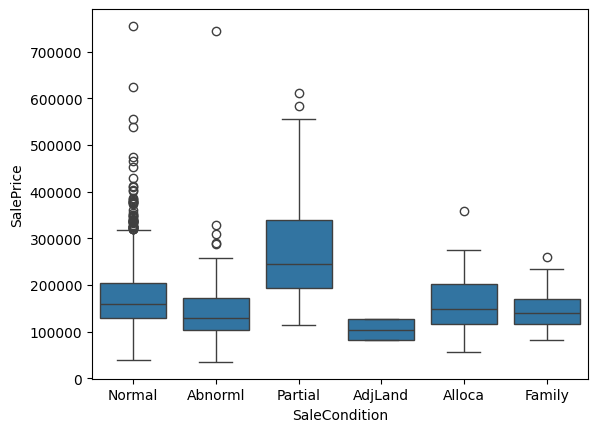

In [13]:
sns.boxplot(y='SalePrice', x='SaleCondition', data=df)

<Axes: xlabel='YearBuilt_bin', ylabel='count'>

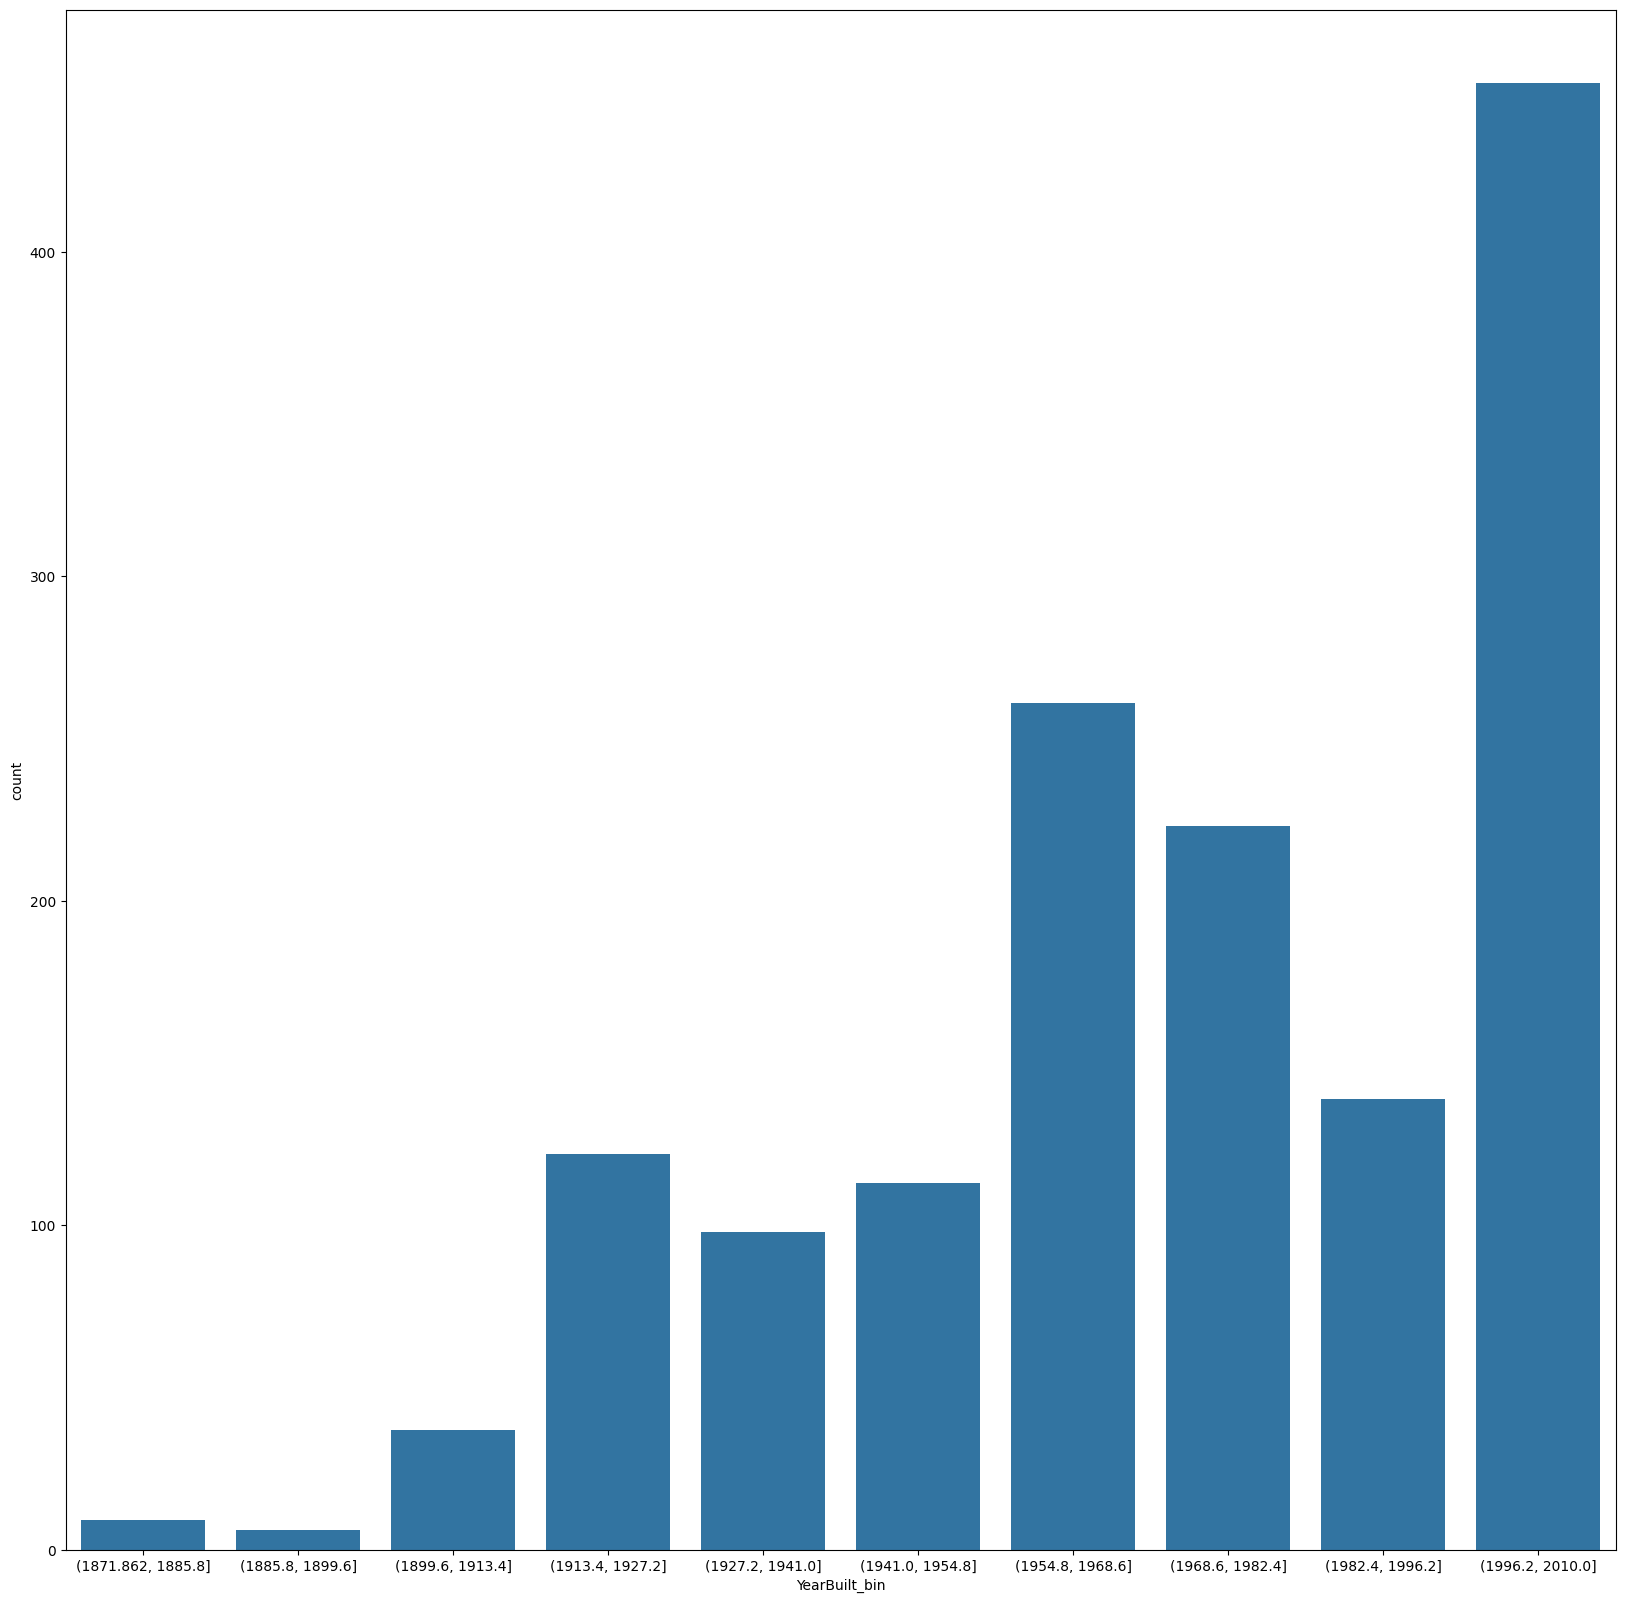

In [14]:
plt.figure(figsize=(20,20))
sns.set_context(font_scale=10)
df['YearBuilt_bin'] = pd.cut(df['YearBuilt'], bins=10)
sns.countplot(x='YearBuilt_bin', data=df)